In [3]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir(os.path.pardir)

In [4]:
import yaml
import matplotlib.pyplot as plt

from src.orchestrator import BacktestOrchestrator
from src.analytics import BacktestAnalyser, FlatPerTrade, render_tearsheet

In [5]:
# Allows asyncio to be run in jup notebook

import nest_asyncio
nest_asyncio.apply()

In [6]:
config = yaml.safe_load(open("config/backtest_kalman.yaml"))
orchestrator = BacktestOrchestrator(config)
trade_log = orchestrator.run()

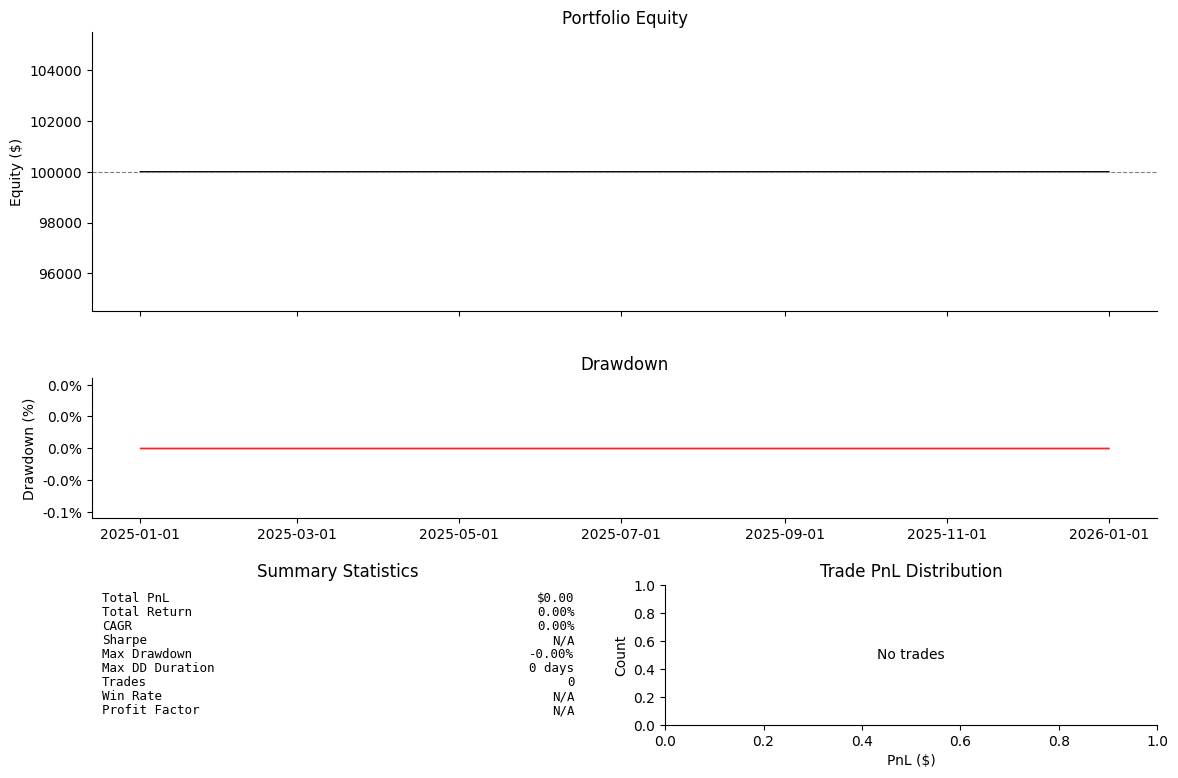

In [7]:
backtest = BacktestAnalyser(
    trade_log = trade_log,
    market_history = orchestrator.market_history,
    initial_capital = 100000,
    cost_model = FlatPerTrade(cost = 0)
)

results = backtest.run()

fig = render_tearsheet(result=results)
fig.savefig("data/processed/kalman_backtest_tearsheet.pdf")
plt.show()

In [15]:
from src.strategy import KalmanOUBertramStrategy

strategy : KalmanOUBertramStrategy = orchestrator._strategy


print(strategy._latest_price)
print(strategy._short_threshold)
print(len(strategy._spread_buffer))
print(strategy._tick_count)

{'ETH-USD': 2966.67724609375, 'BTC-USD': 87501.953125}
None
252
8544
